# Constrained and unconstrained mean-field calculations

By default `get_mean_field_hamiltonian` lets every Wick-contraction channel (charge order,
magnetism, pairing, ...) develop freely. Passing `constrains=[...]` (e.g. `"no_charge"`,
`"no_SC"`) forcibly zeroes out specific channels every iteration, useful to isolate the physics of
a single instability or to forbid an unwanted symmetry breaking. Below, a honeycomb bilayer-like
flake at half filling is converged with and without a `"no_charge"` constraint: without it, the SCF
develops a charge-disproportionated state; with it, only the bands shift rigidly and stay
charge-uniform.

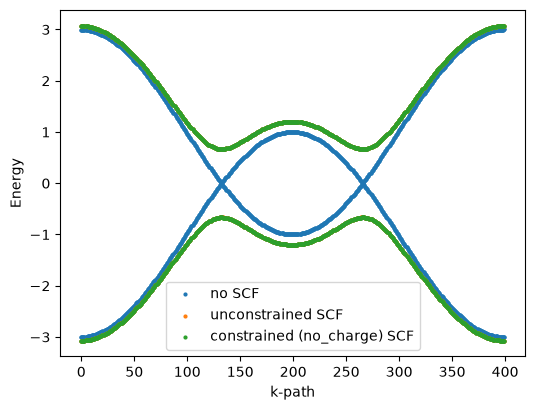

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
g = geometry.honeycomb_lattice()
g = g.get_supercell(1)
h = g.get_hamiltonian()
U = 3.0
filling = 0.5

h_free = h.get_mean_field_hamiltonian(U=U,filling=filling,mf="random")
h_constrained = h.get_mean_field_hamiltonian(U=U,filling=filling,mf="random",
                                              constrains=["no_charge"])

(k0,e0) = h.get_bands()
(k1,e1) = h_free.get_bands()
(k2,e2) = h_constrained.get_bands()

plt.figure(figsize=(6,4.5))
plt.scatter(k0,e0,s=4,label="no SCF")
plt.scatter(k1,e1,s=4,label="unconstrained SCF")
plt.scatter(k2,e2,s=4,label="constrained (no_charge) SCF")
plt.legend()
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.show()

The constraint is clearest over a plane of interactions. A first-neighbor repulsion $V_1$ favors a
charge density wave, with the two sublattices unequally filled, and the onsite $U$ favors the
antiferromagnet. Converging every point of the $(U,V_1)$ plane without the constraint gives the
charge density wave at large $V_1$ and the antiferromagnet at large $U$; with `"no_charge"` the
charge density wave cannot form, and the antiferromagnet takes over part of its region. A point
where the self-consistent loop does not converge is left blank.

No convergence has been reached in 1000 iterations, stopping


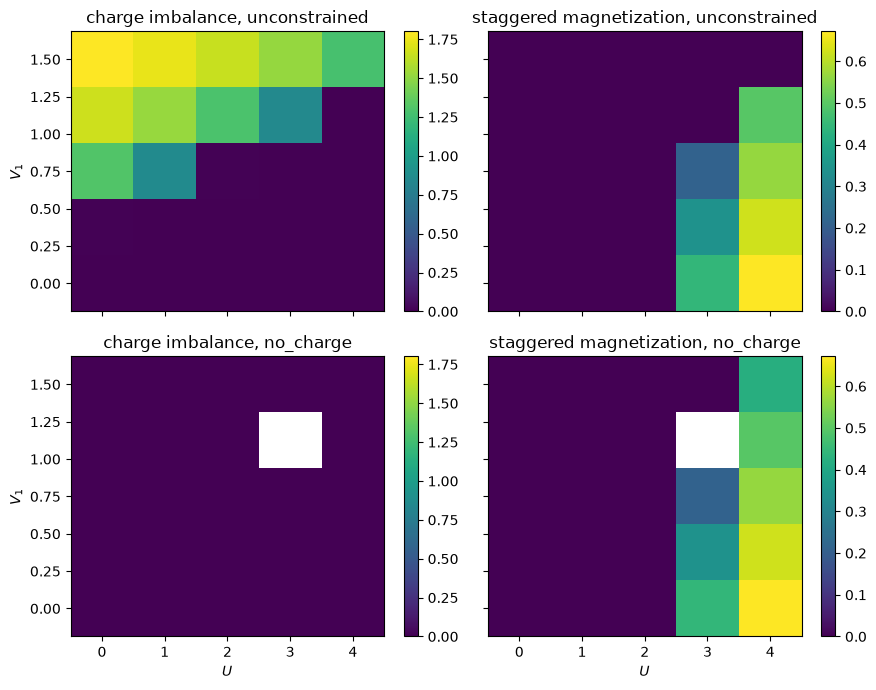

In [2]:
Us = np.linspace(0.,4.,5) # onsite interaction
Vs = np.linspace(0.,1.5,5) # first-neighbor interaction
maps = {} # order parameters, with and without the constraint
for name,cons in [("unconstrained",[]),("no_charge",["no_charge"])]:
    cdw = np.zeros((len(Vs),len(Us))) # charge imbalance between the two sublattices
    afm = np.zeros((len(Vs),len(Us))) # staggered magnetization
    for i,V1 in enumerate(Vs):
        for j,U in enumerate(Us):
            np.random.seed(1) # the same random initial guess for every point
            hmf = h.get_mean_field_hamiltonian(U=U,V1=V1,filling=filling,mf="random",
                                               constrains=cons,nk=8,maxerror=1e-4,verbose=0)
            if hmf is None: # no convergence, left blank in the map
                cdw[i,j] = afm[i,j] = np.nan ; continue
            n = hmf.get_vev() ; m = hmf.get_magnetization()
            cdw[i,j] = np.abs(n[0]-n[1]) ; afm[i,j] = np.linalg.norm(m[0]-m[1])/2
    maps[name] = (cdw,afm)

fig,axs = plt.subplots(2,2,figsize=(9,7),sharex=True,sharey=True)
dU = (Us[1]-Us[0])/2 ; dV = (Vs[1]-Vs[0])/2
for c,label in enumerate(["charge imbalance","staggered magnetization"]):
    vmax = max(np.nanmax(maps[name][c]) for name in maps) # same color scale in both rows
    for r,name in enumerate(maps):
        im = axs[r,c].imshow(maps[name][c],origin="lower",aspect="auto",cmap="viridis",vmin=0.,vmax=vmax,
                             extent=[Us[0]-dU,Us[-1]+dU,Vs[0]-dV,Vs[-1]+dV])
        plt.colorbar(im,ax=axs[r,c]) ; axs[r,c].set_title(f"{label}, {name}")
for ax in axs[1]: ax.set_xlabel("$U$")
for ax in axs[:,0]: ax.set_ylabel("$V_1$")
plt.tight_layout()
plt.show()